# Match Dataset Explorer
Interactive analysis of `matches.jsonl` — validates that the labeled dataset has enough score spread and category coverage to support fine-tuning.

In [1]:
import json
import numpy as np
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Change to matches.jsonl for the full run ───────────────────────────────
MATCHES_FILE = Path("sample_matches.jsonl")

records = []
with MATCHES_FILE.open() as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

# Normalise pair_type for files created before the column existed
if "pair_type" not in df.columns:
    df["pair_type"] = "semantic"

print(f"Loaded {len(df)} pairs")
print(f"  Unique resumes:    {df['resume_id'].nunique()}")
print(f"  Unique jobs:       {df['job_id'].nunique()}")
print(f"  Categories:        {df['resume_category'].nunique()}")
print(f"  Pair types:        {dict(df['pair_type'].value_counts())}")

Loaded 2099 pairs
  Unique resumes:    480
  Unique jobs:       1892
  Categories:        24
  Pair types:        {'random': np.int64(1136), 'semantic': np.int64(963)}


## Premise Check 1 — Score Spread
Fine-tuning needs scores across the full 0–100 range. A dataset that clusters in 40–75 will produce a model that can't distinguish poor from excellent fits.

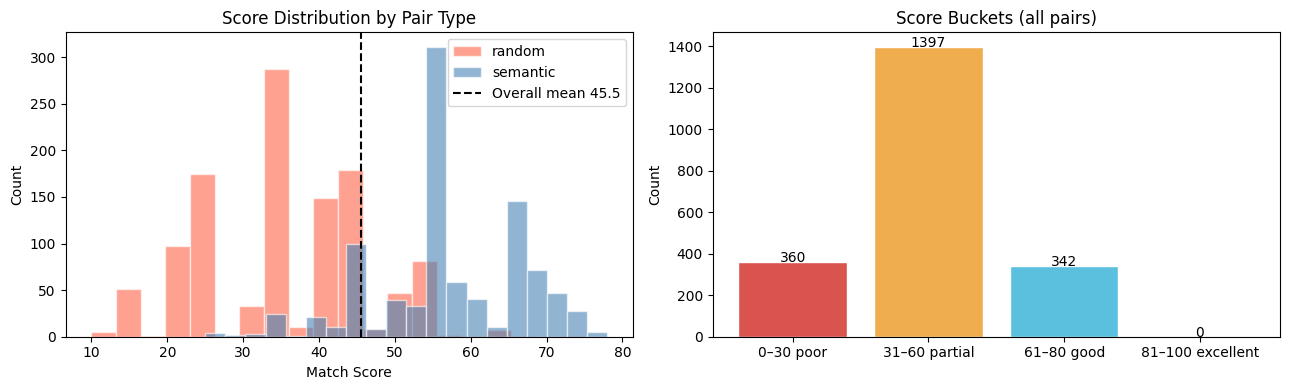

Score stats by pair type:
            count  mean   std   min   25%   50%   75%   max
pair_type                                                  
random     1136.0  35.8  11.1  10.0  25.0  35.0  45.0  75.0
semantic    963.0  57.0   9.6  25.0  52.0  55.0  65.0  78.0

Score range: 10 – 78  (spread=68)
Poor (≤30): 17%   Excellent (≥81): 0%

Premise check: ✅ PASS


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = {"semantic": "steelblue", "random": "tomato"}

for ptype, grp in df.groupby("pair_type"):
    axes[0].hist(grp["match_score"], bins=20, alpha=0.6,
                 label=ptype, color=colors.get(ptype, "grey"), edgecolor="white")

axes[0].axvline(df["match_score"].mean(), color="black", linestyle="--",
                label=f"Overall mean {df['match_score'].mean():.1f}")
axes[0].set_xlabel("Match Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution by Pair Type")
axes[0].legend()

def score_bucket(s):
    if s <= 30:  return "0–30 poor"
    if s <= 60:  return "31–60 partial"
    if s <= 80:  return "61–80 good"
    return               "81–100 excellent"

bucket_order  = ["0–30 poor", "31–60 partial", "61–80 good", "81–100 excellent"]
bucket_colors = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c"]
bucket_counts = df["match_score"].apply(score_bucket).value_counts().reindex(bucket_order, fill_value=0)

bars = axes[1].bar(bucket_order, bucket_counts.values, color=bucket_colors, edgecolor="white")
for bar, v in zip(bars, bucket_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v), ha="center")
axes[1].set_ylabel("Count")
axes[1].set_title("Score Buckets (all pairs)")

plt.tight_layout()
plt.show()

print("Score stats by pair type:")
print(df.groupby("pair_type")["match_score"].describe().round(1).to_string())
print()
spread = df["match_score"].max() - df["match_score"].min()
poor_pct   = (df["match_score"] <= 30).mean() * 100
excl_pct   = (df["match_score"] >= 81).mean() * 100
print(f"Score range: {df['match_score'].min()} – {df['match_score'].max()}  (spread={spread})")
print(f"Poor (≤30): {poor_pct:.0f}%   Excellent (≥81): {excl_pct:.0f}%")
verdict = "✅ PASS" if spread >= 50 and poor_pct > 5 else "⚠️  FAIL — need more score variety (add --add-random-jobs)"
print(f"\nPremise check: {verdict}")

## Premise Check 2 — Category Coverage
All 24 categories should be represented with enough pairs that the fine-tuned model generalises across job domains.

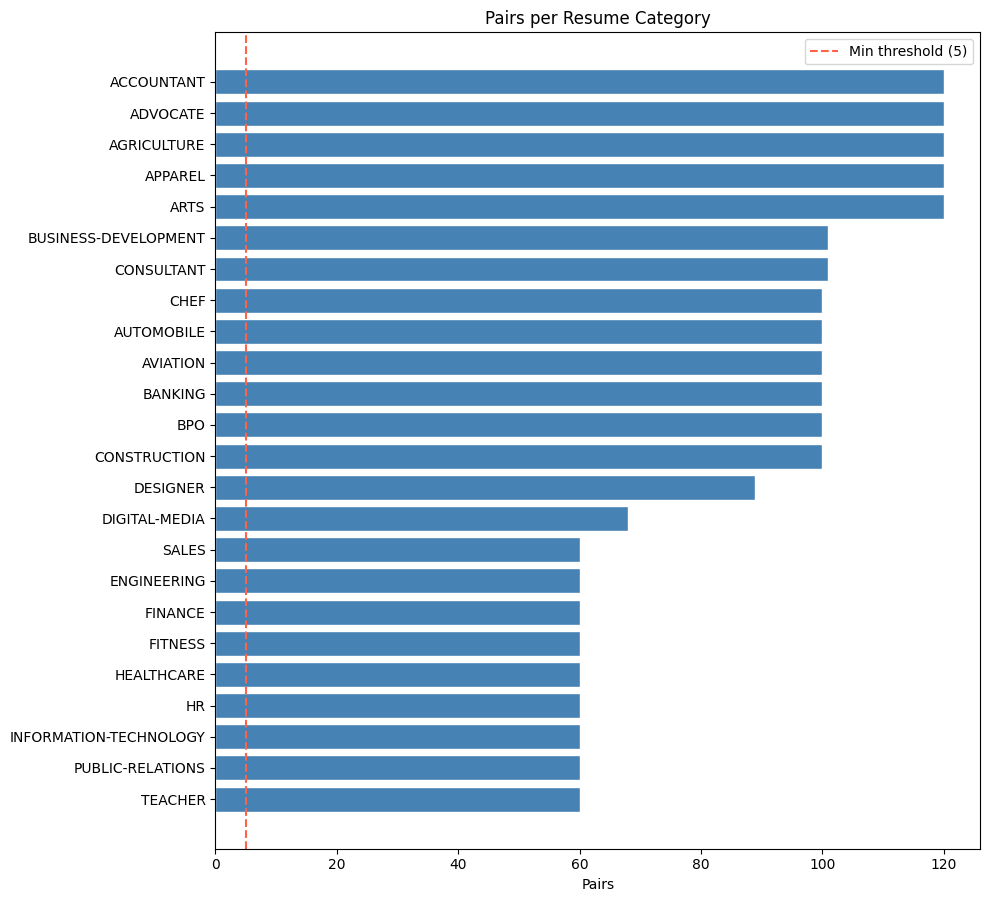

Categories with ≥5 pairs: 24 / 24

Premise check: ✅ PASS


In [3]:
cat_counts = df.groupby("resume_category").size().sort_values()
expected_categories = 24
min_pairs_per_cat   = 5   # floor for meaningful fine-tuning signal

fig, ax = plt.subplots(figsize=(10, max(4, len(cat_counts) * 0.38)))
bar_colors = ["#d9534f" if v < min_pairs_per_cat else "steelblue" for v in cat_counts.values]
ax.barh(cat_counts.index, cat_counts.values, color=bar_colors, edgecolor="white")
ax.axvline(min_pairs_per_cat, color="tomato", linestyle="--", label=f"Min threshold ({min_pairs_per_cat})")
ax.set_xlabel("Pairs")
ax.set_title("Pairs per Resume Category")
ax.legend()
plt.tight_layout()
plt.show()

covered   = (cat_counts >= min_pairs_per_cat).sum()
uncovered = cat_counts[cat_counts < min_pairs_per_cat]
print(f"Categories with ≥{min_pairs_per_cat} pairs: {covered} / {len(cat_counts)}")
if len(uncovered):
    print(f"Under-represented: {list(uncovered.index)}")
verdict = "✅ PASS" if len(cat_counts) >= expected_categories and covered == len(cat_counts) \
    else f"⚠️  FAIL — {expected_categories - len(cat_counts)} categories missing or thin"
print(f"\nPremise check: {verdict}")

## Premise Check 3 — Semantic vs Random Score Gap
Random pairs should score meaningfully lower than semantic pairs. If they don't, the embedding search isn't finding genuinely better matches — the premise breaks.

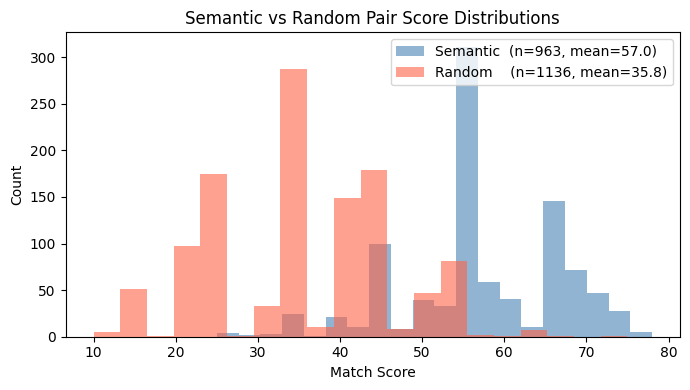

Mean score — semantic: 57.0   random: 35.8   gap: 21.2 pts
Premise check: ✅ PASS


In [4]:
if df["pair_type"].nunique() < 2:
    print("Only one pair_type in this file. Re-run matching.py with --add-random-jobs to enable this check.")
else:
    sem  = df[df["pair_type"] == "semantic"]["match_score"]
    rand = df[df["pair_type"] == "random"]["match_score"]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(sem,  bins=20, alpha=0.6, color="steelblue", label=f"Semantic  (n={len(sem)}, mean={sem.mean():.1f})")
    ax.hist(rand, bins=20, alpha=0.6, color="tomato",    label=f"Random    (n={len(rand)}, mean={rand.mean():.1f})")
    ax.set_xlabel("Match Score")
    ax.set_ylabel("Count")
    ax.set_title("Semantic vs Random Pair Score Distributions")
    ax.legend()
    plt.tight_layout()
    plt.show()

    gap = sem.mean() - rand.mean()
    print(f"Mean score — semantic: {sem.mean():.1f}   random: {rand.mean():.1f}   gap: {gap:.1f} pts")
    verdict = "✅ PASS" if gap >= 10 else "⚠️  WARN — gap < 10 pts; semantic search may not be finding strong matches"
    print(f"Premise check: {verdict}")

## Premise Check 4 — Distance vs Score Correlation
Cosine distance should correlate negatively with match score *within* semantic pairs (closer = higher score). If there's no signal, embeddings aren't useful for retrieval.

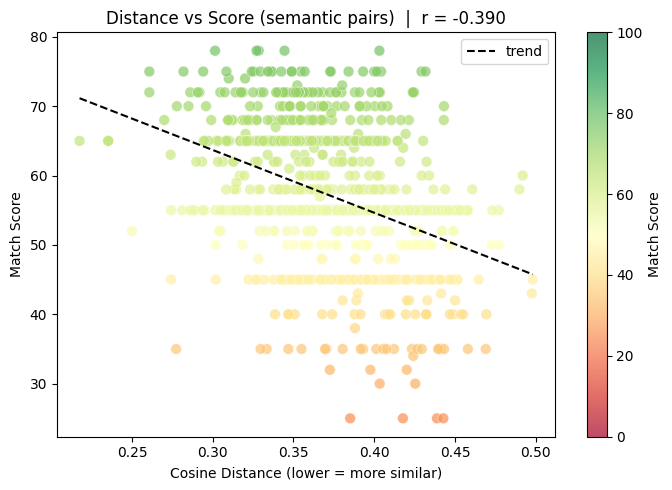

Pearson r (distance vs score, semantic pairs): -0.390
  Negative = closer embedding → higher score  ✅
  Positive = closer embedding → lower score   ⚠️  (over-qualification effect or noisy embeddings)

Premise check: ✅ PASS


In [5]:
sem_df = df[(df["pair_type"] == "semantic") & df["cosine_distance"].notna()].copy()

if len(sem_df) < 5:
    print("Not enough semantic pairs yet to assess correlation.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        sem_df["cosine_distance"], sem_df["match_score"],
        c=sem_df["match_score"], cmap="RdYlGn", vmin=0, vmax=100,
        alpha=0.7, edgecolors="white", linewidth=0.4, s=60
    )
    plt.colorbar(scatter, ax=ax, label="Match Score")

    z = np.polyfit(sem_df["cosine_distance"], sem_df["match_score"], 1)
    xs = np.linspace(sem_df["cosine_distance"].min(), sem_df["cosine_distance"].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), color="black", linestyle="--", linewidth=1.5, label="trend")

    corr = sem_df["cosine_distance"].corr(sem_df["match_score"])
    ax.set_xlabel("Cosine Distance (lower = more similar)")
    ax.set_ylabel("Match Score")
    ax.set_title(f"Distance vs Score (semantic pairs)  |  r = {corr:.3f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Pearson r (distance vs score, semantic pairs): {corr:.3f}")
    print(f"  Negative = closer embedding → higher score  ✅")
    print(f"  Positive = closer embedding → lower score   ⚠️  (over-qualification effect or noisy embeddings)")
    verdict = "✅ PASS" if corr < -0.1 else ("⚠️  WEAK" if corr < 0.1 else "⚠️  REVERSED — check embedding quality")
    print(f"\nPremise check: {verdict}")

## Score by Category
Checks whether scores vary across domains — a model that only knows HR scores won't generalise.

,mean,median,std,count
resume_category,,,,
HEALTHCARE,52.2,55.0,14.0,60
INFORMATION-TECHNOLOGY,51.9,55.0,14.1,60
FINANCE,51.8,55.0,15.1,60
HR,51.0,55.0,13.2,60
ENGINEERING,49.9,55.0,14.5,60
PUBLIC-RELATIONS,49.8,53.5,12.9,60
FITNESS,49.0,48.0,13.6,60
TEACHER,48.6,55.0,13.5,60
DIGITAL-MEDIA,48.6,53.5,15.3,68


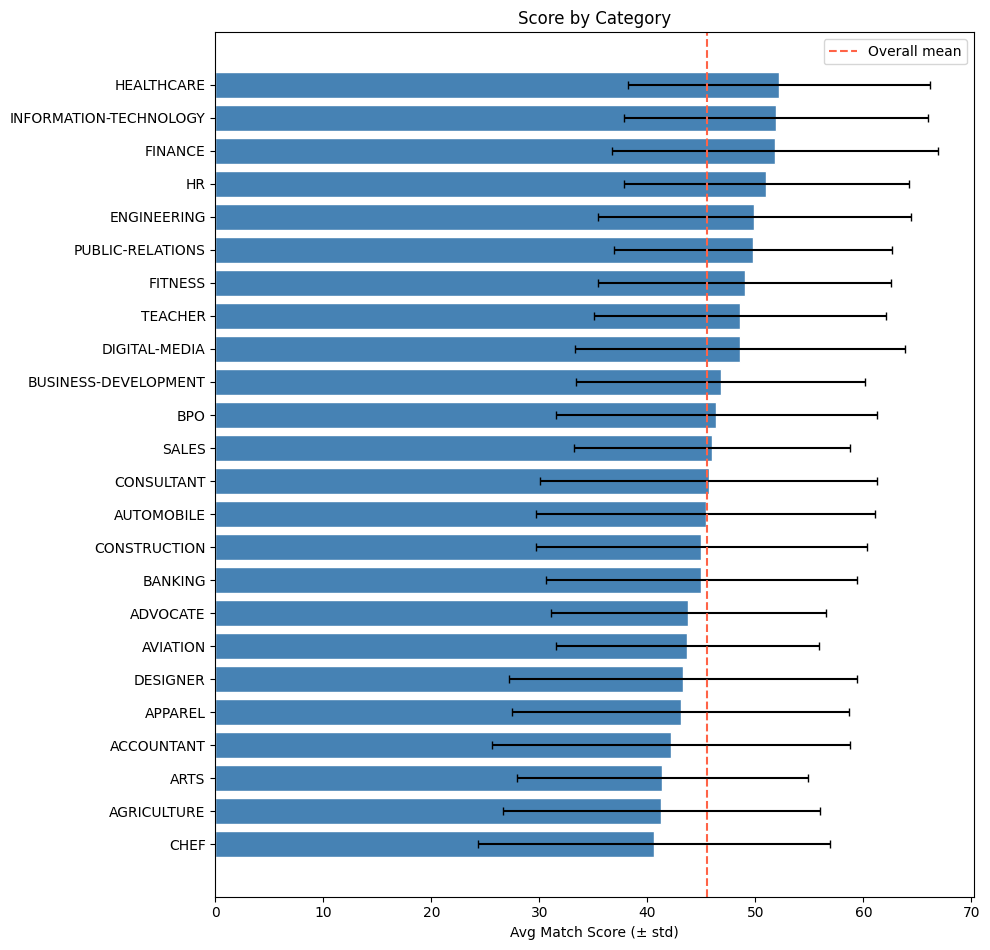

In [6]:
cat_stats = (
    df.groupby("resume_category")["match_score"]
    .agg(["mean", "median", "std", "count"])
    .round(1)
    .sort_values("mean", ascending=False)
)
display(cat_stats)

plot_cats = cat_stats[cat_stats["count"] > 1].sort_values("mean")
if len(plot_cats) > 1:
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_cats) * 0.4)))
    ax.barh(plot_cats.index, plot_cats["mean"], xerr=plot_cats["std"],
            color="steelblue", edgecolor="white", capsize=3)
    ax.axvline(df["match_score"].mean(), color="tomato", linestyle="--", label="Overall mean")
    ax.set_xlabel("Avg Match Score (± std)")
    ax.set_title("Score by Category")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Need multiple categories — run with --sample-per-category.")

## Top ATS Keywords Missing

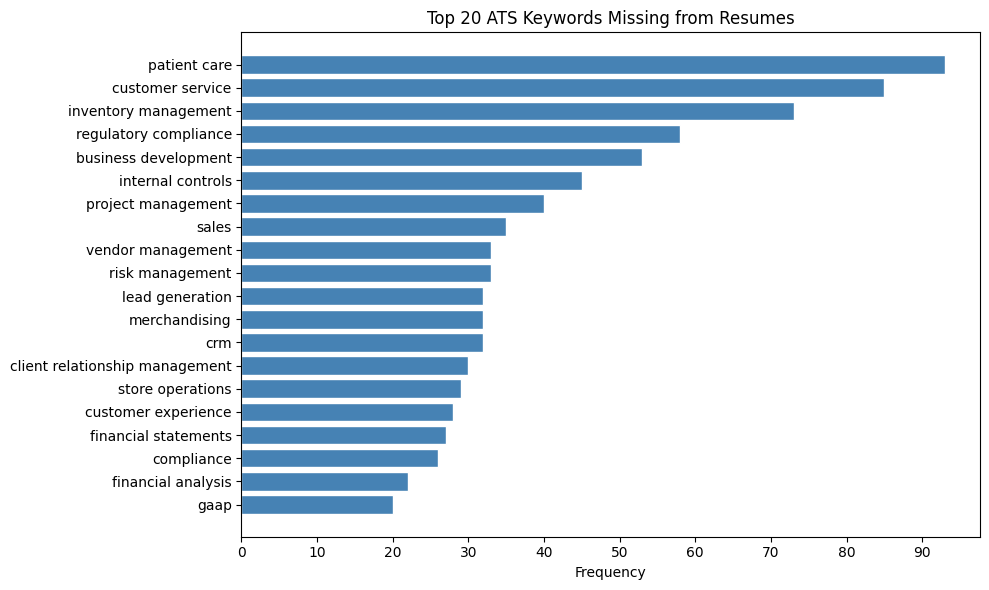

In [7]:
all_keywords = [kw.lower().strip() for row in df["ats_keywords_missing"] for kw in (row or [])]
kw_df = pd.DataFrame(Counter(all_keywords).most_common(20), columns=["keyword", "count"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(kw_df["keyword"][::-1], kw_df["count"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Frequency")
ax.set_title("Top 20 ATS Keywords Missing from Resumes")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## Recommended Activities

In [8]:
has_acts = df["recommended_activities"].apply(lambda x: bool(x))
print(f"With activities: {has_acts.sum()} / {len(df)}  ({has_acts.mean()*100:.0f}%)")
print()
for _, row in df[has_acts][["resume_category", "job_title", "match_score", "recommended_activities"]].iterrows():
    print(f"[{row['resume_category']}]  {row['job_title']}  (score: {row['match_score']})")
    for act in row["recommended_activities"]:
        print(f"    • {act}")
    print()

With activities: 229 / 2099  (11%)

[ACCOUNTANT]  Title: Bookkeeper  (score: 45)
    • Consider obtaining QuickBooks Online Certification
    • Complete a short course or workshop on small business bookkeeping and financial reporting
    • Volunteer or take on freelance bookkeeping projects using QuickBooks to gain practical experience

[ACCOUNTANT]  Fiber Technician, Kansas City, MO  (score: 35)
    • Complete telecommunications and fiber optic technician training programs or certifications (e.g., FOA certification, fiber optic technician courses).
    • Gain hands-on experience through internships, volunteer work, or entry-level field roles in telecommunications or network maintenance.
    • Participate in online courses or workshops on DWDM, Ethernet/IP troubleshooting, and fiber optic installation to build relevant technical knowledge.

[ACCOUNTANT]  Legal Conflicts Assistant  (score: 25)
    • Volunteer or freelance work in legal administration or paralegal tasks
    • Online lega

## Inspect Individual Records

In [9]:
IDX = 0   # change to explore any pair

r = records[IDX]
print(f"Resume:   [{r['resume_category']}]  id={r['resume_id']}")
print(f"Job:      {r['job_title']} @ {r['job_company']} ({r.get('job_location','')})")
print(f"Type:     {r.get('pair_type','—')}   dist={r.get('cosine_distance','—')}")
print(f"Score:    {r['match_score']}  |  {r.get('experience_level_fit','—')}")
print(f"\nRationale:\n  {r['rationale']}")
print("\nStrengths:",  [f"+{s}" for s in r.get("matching_strengths", [])])
print("Gaps:",        [f"-{g}" for g in r.get("skill_gaps", [])])
print("ATS missing:", r.get("ats_keywords_missing", []))
print("Improvements:")
for imp in r.get("resume_improvements", []):
    print(f"  → {imp}")
acts = r.get("recommended_activities")
if acts:
    print("Activities:")
    for a in acts: print(f"  ★ {a}")

Resume:   [ACCOUNTANT]  id=38847011
Job:      Senior Payroll & Benefits Administrator @ Pivotal Talent Search (Chicago, IL)
Type:     semantic   dist=0.302318
Score:    65  |  well-matched

Rationale:
  The candidate has extensive payroll processing experience, including working with systems like Kronos, Nextgen, and ADP, which are relevant to the job. They demonstrate strong background in payroll administration, compliance, and system management, aligning well with the responsibilities of the Senior Payroll & Benefits Administrator role.

Strengths: ['+Strong experience with payroll systems such as Kronos, Nextgen, and ADP', '+Experience managing large payrolls and ensuring compliance with policies', '+Proven ability to process multi-state payroll and handle benefits and tax documentation', '+Capability to update and maintain payroll systems and records']
Gaps: ['-Direct experience with Ceridian Dayforce, as mentioned in the JD', '-Experience specifically with multi-company payroll pr

## Filter & Search

In [10]:
# High-confidence good matches
df[df["match_score"] >= 70][["resume_category","job_title","job_company","match_score","pair_type","experience_level_fit"]].sort_values("match_score", ascending=False)

,resume_category,job_title,job_company,match_score,pair_type,experience_level_fit
1712,FITNESS,Group Fitness Instructor,,78,semantic,well-matched
348,AUTOMOBILE,SIU Investigator,Allied Universal,78,semantic,well-matched
307,AUTOMOBILE,DataStage Developer,Compunnel Inc.,78,semantic,well-matched
198,APPAREL,Senior Internal Auditor,Robert Half,78,semantic,well-matched
661,CONSTRUCTION,Loan Clerk,Edge Home Finance Corporation,78,semantic,well-matched
...,...,...,...,...,...,...
475,BANKING,Service Provider,Syracuse University,70,semantic,well-matched
589,BUSINESS-DEVELOPMENT,Technical Business Development Manager - Light...,Seoul Semiconductor,70,semantic,well-matched
588,BUSINESS-DEVELOPMENT,Global Brand Manager,Interfacio Ltd,70,semantic,well-matched
1643,FINANCE,Financial Services Manager,,70,semantic,well-matched


In [ ]:
# Low-score pairs — should mostly be random type
df[df["match_score"] <= 30][["resume_category","job_title","match_score","pair_type","cosine_distance"]].sort_values("match_score")

In [11]:
# Filter by category
CATEGORY = "INFORMATION-TECHNOLOGY"
df[df["resume_category"] == CATEGORY][["job_title","job_company","match_score","pair_type","experience_level_fit","cosine_distance"]].sort_values("match_score", ascending=False)

,job_title,job_company,match_score,pair_type,experience_level_fit,cosine_distance
1887,Network Ops Manager,System Soft Technologies,75,semantic,well-matched,0.348859
1880,NOC/ Network Operations/ Global Program Direct...,Vantage Point Consulting Inc.,70,semantic,well-matched,0.354158
1881,Network Engineer at Remote ( Full Time ),BURGEON IT SERVICES,68,semantic,over-qualified,0.321667
1892,IT SPECIALIST (CUSTSPT) with Security Clearance,ClearanceJobs,68,semantic,well-matched,0.309513
1860,Unix Systems Administrator with Security Clear...,ClearanceJobs,67,semantic,well-matched,0.338963
1876,Remote Customer Service Representative,,65,semantic,well-matched,0.353979
1895,Director Program Management Office,CornerStone Technology Talent Services,65,semantic,good fit,0.297402
1896,Program Manager,"PMO Partners, LLC",65,semantic,good fit,0.319415
1889,Senior Project Manager,AspiringIT,65,semantic,well-matched,0.351810
1866,Information Technology Engineer,"Gateway Technical Services, dba DSN",65,semantic,well-matched,0.361314
